# Accessing EFEHR Earthquake Catalogue Services - and a Look at Earthquake Recurrence

In this Jupyter notebook we will demonstrate how to use two European earthquake catalogue services to create a local earthquake catalogue for a region, before then assessing its completeness and estimating recurrence.

The two catalogue services are:

1) The European-Mediterranean Earthquake Catalogue (EMEC) (https://emec.gfz.de) built and hosted by GFZ Helmholtz Centre for Geosciences. This catalogue covers the period 1900 AD - 2021 AD, harmonising information from various local, national and international bulletins and special studies. The harmonised catalogue provides a single entry for time, location and moment magnitude (or equivalent proxy) for each earthquake.

2) The European Preinstrumental Earthquake Catalogue (EPICA) (https://www.emidius.eu/epica/) from the European Archive of Historial Earthquake Data (AHEAD), built and hosted by the Insituto Nazionale di Geofisica e Vulcanolgia (INGV). This catalogue covers the period 1000 AD - 1899 AD, creating a harmonised parametric earthquake catalogue processed from macroseismic intensity data.

Here we will show you how to query both webservices and join the two catalogues together.

In [1]:
%load_ext autoreload
%autoreload 2
import warnings; warnings.filterwarnings("ignore")

### Setup

Here we need some standard Python tools for handling data and webservice requests. We will also use Obspy for some of the catalogue tools

In [2]:
%matplotlib inline
import requests
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm
import obspy

First, we can create a simple basemap for our target region using some available administrative boundary shapefiles.

(36.0, 41.0)

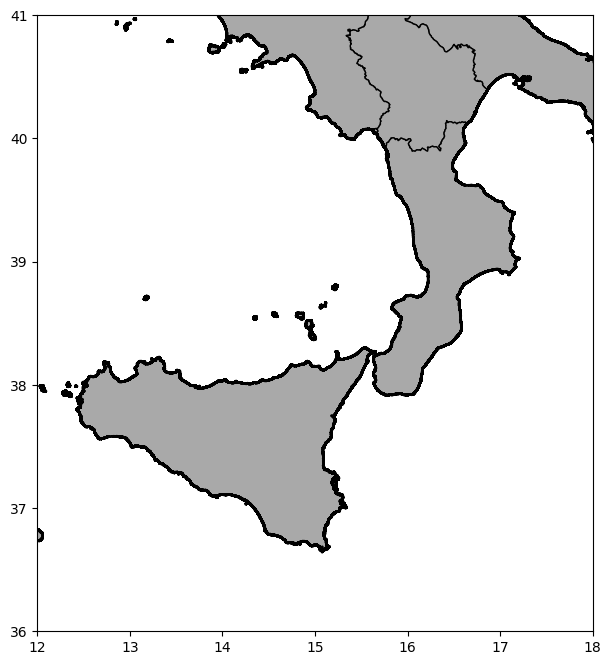

In [3]:
ita0 = gpd.read_file("./data/gadm40_ITA_shp/gadm40_ITA_0.shp")
ita1 = gpd.read_file("./data/gadm40_ITA_shp/gadm40_ITA_1.shp")
w, s, e, n = bbox = (12.0, 36.0, 18.0, 41.0)

fig, ax = plt.subplots(1, 1, figsize=(8,8))
ax = ita1.plot(color="darkgrey", edgecolor="k", lw=1.0,ax=ax)
ax = ita0.plot(color="None", lw=2, ax=ax)
ax.set_xlim(w, e)
ax.set_ylim(s, n)

# Download Catalogue from EMEC Webservice

Starting with the EMEC webservice, we can download a catalogue for a target region by first constructing the FDSN event url ...

Here we need to define the URL of the webservice itself, and combine these with the query options. For this selection we will consider earthquakes in the time period 1 January 1900 to 31 December 2021, within the bounding box shown in the figure above, and with a minimum magnitude of 3.0.

The query can return the catalogue in FDSN Event text format or in QuakeML. We will use the simple text format below.

In [4]:
EMEC_URL = "https://emec.gfz-potsdam.de/fdsnws/event/1/query?"
# Set the webservice query options
emec_query = {
    "starttime": "1900-01-01T00:00:00",
    "endtime": "2022-01-01T00:00:00",
    "minlatitude": s,
    "maxlatitude": n,
    "minlongitude": w,
    "maxlongitude": e,
    "minmagnitude": 3.0,
    "maxmagnitude": None,
    "format": "text"
}

# Build the URL
query_string = []
for key, val in emec_query.items():
    if val:
        query_string.append("{:s}={:s}".format(key, str(val)))
emec_query_url = EMEC_URL + "&".join(query_string)
print(emec_query_url)

https://emec.gfz-potsdam.de/fdsnws/event/1/query?starttime=1900-01-01T00:00:00&endtime=2022-01-01T00:00:00&minlatitude=36.0&maxlatitude=41.0&minlongitude=12.0&maxlongitude=18.0&minmagnitude=3.0&format=text


Now with the url string built, we can use pandas to read this information and pass it to a dataframe. We will use the EventID as the index to the dataframe

In [5]:
df = pd.read_csv(emec_query_url, sep="|")
df.set_index("#EventID", inplace=True, drop=True)
df

,Time,Latitude,Longitude,Depth/km,Author,Catalog,Contributor,ContributorID,MagType,Magnitude,MagAuthor,EventLocationName,EventType
#EventID,,,,,,,,,,,,,
1901051162000,1901-05-11T11:10:00,37.62,15.03,NaN,NaN,EMEC-2021,NaN,NaN,Mw,3.75,NaN,NaN,earthquake
1901062062001,1901-06-20T17:30:00,38.88,16.54,NaN,NaN,EMEC-2021,NaN,NaN,Mw,4.31,NaN,NaN,earthquake
1901121362001,1901-12-13T00:10:22,38.65,16.19,NaN,NaN,EMEC-2021,NaN,NaN,Mw,4.81,NaN,NaN,earthquake
1903021062001,1903-02-10T08:04:00,36.90,15.01,NaN,NaN,EMEC-2021,NaN,NaN,Mw,4.32,NaN,NaN,earthquake
1903071362001,1903-07-13T08:19:00,37.15,14.58,NaN,NaN,EMEC-2021,NaN,NaN,Mw,4.14,NaN,NaN,earthquake
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20201222200005,2020-12-22T20:27:24,36.93,14.41,29.5,NaN,EMEC-2021,NaN,NaN,Mw,4.52,NaN,NaN,earthquake
20201231200018,2020-12-31T20:30:52,37.69,14.96,9.6,NaN,EMEC-2021,NaN,NaN,Mw,3.52,NaN,NaN,earthquake
20201231200017,2020-12-31T20:58:10,37.69,14.96,9.6,NaN,EMEC-2021,NaN,NaN,Mw,3.64,NaN,NaN,earthquake


With the catalogue downloaded, we can create a simple scatter plot over our basemap showing the location of the earthquakes with the marker size proportional to magnitude and the colour proportional to depth.

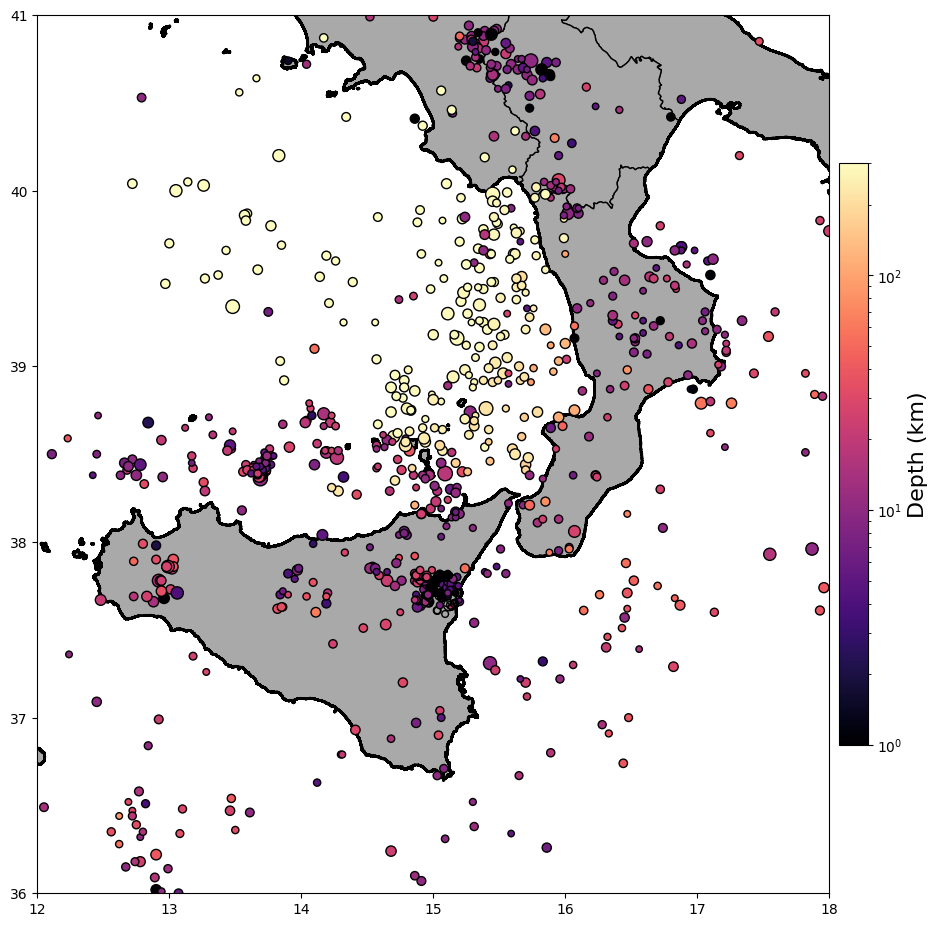

In [22]:
fig, ax = plt.subplots(1,1, figsize=(10,10))
ax = ita1.plot(color="darkgrey", edgecolor="k", lw=1.0,ax=ax)
ax = ita0.plot(color="None", lw=2, ax=ax)
cax = ax.scatter(df["Longitude"], df["Latitude"], c=df["Depth/km"],
                 s=0.5 * df["Magnitude"] ** 3.0,
                 cmap="magma", norm=LogNorm(1.0, 300.0), edgecolor="k")
cbar = fig.colorbar(cax, pad=0.01, shrink=0.60)
cbar.ax.set_ylabel("Depth (km)", fontsize=16)
ax.set_xlim(w, e)
ax.set_ylim(s, n)
fig.tight_layout()

# Now access data from the AHEAD Event Webservice

The AHEAD EPICA event webservice also provides its catalogue in FDSN event format. So we can query this in the same manner as for the EMEC webservice. Here the time period spans 1 January 1000 AD to 31 December 1899.

In [6]:
AHEAD_URL = "https://www.emidius.eu/fdsnws/event/1/query?"
ahead_query = {
    "starttime": "1000-01-01T00:00:00",
    "endtime": "1900-01-01T00:00:00",
    "minlatitude": s,
    "maxlatitude": n,
    "minlongitude": w,
    "maxlongitude": e,
    "minmagnitude": 3.0,
    "maxmagnitude": None,
    "orderby": "time-asc",  # Order the events in ascending order of time
    "limit": 1000,
    "format": "text"
}
query_string = []
for key, val in ahead_query.items():
    if val:
        query_string.append("{:s}={:s}".format(key, str(val)))
ahead_query_url = AHEAD_URL + "&".join(query_string)
print(ahead_query_url)

https://www.emidius.eu/fdsnws/event/1/query?starttime=1000-01-01T00:00:00&endtime=1900-01-01T00:00:00&minlatitude=36.0&maxlatitude=41.0&minlongitude=12.0&maxlongitude=18.0&minmagnitude=3.0&orderby=time-asc&limit=1000&format=text


And, once again, read this text format into a dataframe using pandas

In [7]:
df_ahead = pd.read_csv(ahead_query_url, sep="|")
df_ahead.set_index("#EventID", inplace=True, drop=True)
df_ahead

,Time,Latitude,Longitude,Depth/km,Author,Catalog,Contributor,ContributorID,MagType,Magnitude,MagAuthor,EventLocationName,EventType
#EventID,,,,,,,,,,,,,
quakeml:eu.ahead/event/11250607_1100_000,1125-06-07T11:00:--,37.073,15.286,NaN,AHEAD,EPICAv1.1,CFTI5med; CPTI15,NaN,Mw,5.80,EPICAv1.1,Siracusa,earthquake
quakeml:eu.ahead/event/11690204_0700_000,1169-02-04T07:00:--,37.215,14.949,NaN,AHEAD,EPICAv1.1,CFTI5med; CPTI15,NaN,Mw,6.48,EPICAv1.1,Sicilia orientale,earthquake
quakeml:eu.ahead/event/11720926_1340_000,1172-09-26T13:40:--,38.185,15.555,NaN,AHEAD,EPICAv1.1,CFTI5med; CPTI15,NaN,Mw,5.56,EPICAv1.1,Messina,earthquake
quakeml:eu.ahead/event/11840524_0000_000,1184-05-24,39.395,16.194,NaN,AHEAD,EPICAv1.1,CFTI5med; CPTI15,NaN,Mw,6.75,EPICAv1.1,Valle del Crati,earthquake
quakeml:eu.ahead/event/11980000_0000_001,1198------,40.822,14.123,NaN,AHEAD,EPICAv1.1,MOLAL008; CPTI15,NaN,Mw,3.37,EPICAv1.1,Pozzuoli,earthquake
...,...,...,...,...,...,...,...,...,...,...,...,...,...
quakeml:eu.ahead/event/18981103_0559_000,1898-11-03T05:59:--,37.259,14.546,NaN,AHEAD,EPICAv1.1,AZZBA000; CPTI15,NaN,Mw,4.58,EPICAv1.1,Caltagirone,earthquake
quakeml:eu.ahead/event/18990327_0119_000,1899-03-27T01:19:--,40.969,13.321,NaN,AHEAD,EPICAv1.1,MOLAL008; CPTI15,NaN,Mw,3.74,EPICAv1.1,Isola di Ventotene,earthquake
quakeml:eu.ahead/event/18990627_2115_000,1899-06-27T21:15:--,38.556,14.844,NaN,AHEAD,EPICAv1.1,MOLAL008; CPTI15,NaN,Mw,4.20,EPICAv1.1,Isola di Salina,earthquake


Now we can create a full catalogue (1000 AD to 2021 AD) by concatenating the two data frames into a single catalogue dataframe

In [8]:
catalogue = pd.concat([df_ahead, df], axis=0)
catalogue

,Time,Latitude,Longitude,Depth/km,Author,Catalog,Contributor,ContributorID,MagType,Magnitude,MagAuthor,EventLocationName,EventType
#EventID,,,,,,,,,,,,,
quakeml:eu.ahead/event/11250607_1100_000,1125-06-07T11:00:--,37.073,15.286,NaN,AHEAD,EPICAv1.1,CFTI5med; CPTI15,NaN,Mw,5.80,EPICAv1.1,Siracusa,earthquake
quakeml:eu.ahead/event/11690204_0700_000,1169-02-04T07:00:--,37.215,14.949,NaN,AHEAD,EPICAv1.1,CFTI5med; CPTI15,NaN,Mw,6.48,EPICAv1.1,Sicilia orientale,earthquake
quakeml:eu.ahead/event/11720926_1340_000,1172-09-26T13:40:--,38.185,15.555,NaN,AHEAD,EPICAv1.1,CFTI5med; CPTI15,NaN,Mw,5.56,EPICAv1.1,Messina,earthquake
quakeml:eu.ahead/event/11840524_0000_000,1184-05-24,39.395,16.194,NaN,AHEAD,EPICAv1.1,CFTI5med; CPTI15,NaN,Mw,6.75,EPICAv1.1,Valle del Crati,earthquake
quakeml:eu.ahead/event/11980000_0000_001,1198------,40.822,14.123,NaN,AHEAD,EPICAv1.1,MOLAL008; CPTI15,NaN,Mw,3.37,EPICAv1.1,Pozzuoli,earthquake
...,...,...,...,...,...,...,...,...,...,...,...,...,...
20201222200005,2020-12-22T20:27:24,36.930,14.410,29.5,NaN,EMEC-2021,NaN,NaN,Mw,4.52,NaN,NaN,earthquake
20201231200018,2020-12-31T20:30:52,37.690,14.960,9.6,NaN,EMEC-2021,NaN,NaN,Mw,3.52,NaN,NaN,earthquake
20201231200017,2020-12-31T20:58:10,37.690,14.960,9.6,NaN,EMEC-2021,NaN,NaN,Mw,3.64,NaN,NaN,earthquake


We can save this to csv using pandas

In [35]:
catalogue.to_csv("./SItaly_catalogue_1000_2021.csv", sep=",")

### Cleaning up the date and time information

Of course when joining together two catalogues there are some fields that are relevant to one and not the other. Ultimately, what we are most concerned with is date/time, location (including depth) and magnitude. Location and magnitude are more or less harmonized parametrically, but the date/time information is messy.

For many historical (and early instrumental) earthquakes the date and time information can be incomplete with respect to a fully formatted Python datetime structure. For the analyses that follow, we need to at least assign a date (year, month and day) to each event. For the very older historical earthquakes the month and day may not be known - here we just assign these to a default value of 1. 

The function below will cleanup the datetime and assign new columns for year, month and day

In [10]:
def time_cleanup(dframe):
    """Transforms the time column into a pandas datetime object and
    adds, year, month and day columns
    """
    times = []
    year = []
    month = []
    day = []
    for evid, row in dframe.iterrows():
        if "T" in row.Time:
            # Has YYYY-MM-ddThh:mm:ss format
            date, time = row.Time.split("T")
            yr, mn, dy = date.split("-")
            year.append(int(yr))
            month.append(int(mn))
            day.append(int(dy))
            time = time.replace("--", "00") if "--" in time else time
            hh, mm, ss = time.split(":")
        else:
            date = row.Time.split("-")
            yr = date[0]
            year.append(int(yr))
            mn = date[1] if date[1] else "01"
            dy = date[2] if date[2] else "01"
            month.append(int(mn))
            day.append(int(dy))
            date = f"{yr}-{mn}-{dy}"
            time = "01:00:00"
        times.append(np.datetime64(f"{date}T{time}"))
    dframe["datetime"] = pd.to_datetime(times)
    dframe["year"] = np.array(year, dtype=int)
    dframe["month"] = np.array(month, dtype=int)
    dframe["day"] = np.array(day, dtype=int)
    return dframe
    

In [11]:
catalogue = time_cleanup(catalogue.copy())
catalogue

,Time,Latitude,Longitude,Depth/km,Author,Catalog,Contributor,ContributorID,MagType,Magnitude,MagAuthor,EventLocationName,EventType,datetime,year,month,day
#EventID,,,,,,,,,,,,,,,,,
quakeml:eu.ahead/event/11250607_1100_000,1125-06-07T11:00:--,37.073,15.286,NaN,AHEAD,EPICAv1.1,CFTI5med; CPTI15,NaN,Mw,5.80,EPICAv1.1,Siracusa,earthquake,1125-06-07 11:00:00,1125,6,7
quakeml:eu.ahead/event/11690204_0700_000,1169-02-04T07:00:--,37.215,14.949,NaN,AHEAD,EPICAv1.1,CFTI5med; CPTI15,NaN,Mw,6.48,EPICAv1.1,Sicilia orientale,earthquake,1169-02-04 07:00:00,1169,2,4
quakeml:eu.ahead/event/11720926_1340_000,1172-09-26T13:40:--,38.185,15.555,NaN,AHEAD,EPICAv1.1,CFTI5med; CPTI15,NaN,Mw,5.56,EPICAv1.1,Messina,earthquake,1172-09-26 13:40:00,1172,9,26
quakeml:eu.ahead/event/11840524_0000_000,1184-05-24,39.395,16.194,NaN,AHEAD,EPICAv1.1,CFTI5med; CPTI15,NaN,Mw,6.75,EPICAv1.1,Valle del Crati,earthquake,1184-05-24 01:00:00,1184,5,24
quakeml:eu.ahead/event/11980000_0000_001,1198------,40.822,14.123,NaN,AHEAD,EPICAv1.1,MOLAL008; CPTI15,NaN,Mw,3.37,EPICAv1.1,Pozzuoli,earthquake,1198-01-01 01:00:00,1198,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20201222200005,2020-12-22T20:27:24,36.930,14.410,29.5,NaN,EMEC-2021,NaN,NaN,Mw,4.52,NaN,NaN,earthquake,2020-12-22 20:27:24,2020,12,22
20201231200018,2020-12-31T20:30:52,37.690,14.960,9.6,NaN,EMEC-2021,NaN,NaN,Mw,3.52,NaN,NaN,earthquake,2020-12-31 20:30:52,2020,12,31
20201231200017,2020-12-31T20:58:10,37.690,14.960,9.6,NaN,EMEC-2021,NaN,NaN,Mw,3.64,NaN,NaN,earthquake,2020-12-31 20:58:10,2020,12,31


### Look at Completeness

In [13]:
def plot_magnitude_time_density(magnitudes, years, mbins, time_bins,
                                completeness_table=[], vmin=1, vmax=100,
                                filename=None, filetype="png", dpi=300):
    """
    Create a magnitude density plot
    :param magnitudes:
        Vector of magnitudes
    :param years:
        Vector of years
    :param mbins:
        Edges of the magnitude bins
    :param time_bins:
        Edges of the time bins
    :param completeness_table:
        If present, the table of completeness
    If you want to export a figure then:
    filename: Name of the file to save the figure to
    filetype: The file format (try to make it agree with the filename!)
    dpi: The resolution of the figure (dots per inch)
    """
    # Generate a 2-D historgram in terms of magnitude and time
    counter = np.histogram2d(years, magnitudes, bins=(time_bins,mbins))[0]
    # Plot the density
    fig = plt.figure(figsize=(10,6))
    ax = fig.add_subplot(111)
    cax = ax.pcolormesh(time_bins[:-1], mbins[:-1],
                        counter.T, norm=LogNorm(vmin, vmax))
    # Add axes and labels
    ax.set_xlabel("Year", fontsize=16)
    ax.set_ylabel("Magnitude", fontsize=16)
    ax.tick_params(labelsize=14)
    cbar = fig.colorbar(cax)
    cbar.ax.set_ylabel("No. of Events", fontsize=14)
    plt.grid(which="both")
    # If a completeness table is given add on a step line
    if len(completeness_table):
        completeness = np.array(completeness_table)
        ax.step(completeness[:, 0], completeness[:, 1], "r--", lw=2)
    # If the filename is specified then export to file 
    if filename:
        plt.savefig(filename, format=filetype, dpi=300, bbox_inches="tight")


color_cycle = ["b", "g", "r", "gold", "k", "c", "lightpink", "darkviolet", "brown", "grey"]


def cumulative_rates(magnitudes, years, completeness_table,
                      filename=None, filetype="png", dpi=300):
    """
    Produces a plot of the cumulative number of events in
    each magnitude bin to identify completeness
    """
    magnitudes = magnitudes.to_numpy()
    years = years.to_numpy()
    if isinstance(completeness_table, np.ndarray) and len(completeness_table.shape) == 1:
        # If the completeness table is a single vector then it is just a vector
        # of lower magnitude bins
        min_year = np.min(years)
        ctable = np.column_stack([min_year + np.zeros(completeness_table.shape[0]),
                                  completeness_table])
    elif isinstance(completeness_table, list):
        # Completeness table is a list, make it an array
        ctable = np.array(completeness_table)
    else:
        raise ValueError("Completeness table type not recognised")
        
    bins = ctable[:, 1]
    fig, ax = plt.subplots(1, 1, figsize=(12,12))
    for i in range(len(bins) - 1):
        #  Create a boolean vector of events within a given
        #  magnitude range - then convert to floats
        idx = np.logical_and(magnitudes >= bins[i],
                             magnitudes < bins[i + 1]).astype(float)
        if not np.any(idx):
            # If no earthquakes, skip ahead
            continue
        # Generate the cumulative number of events
        count = np.cumsum(idx)
        # Normalise so that the cumulative number of events per
        # bin goes to 1
        count /= float(count[-1])
        # Plot the cumulative number of countes
        ax.plot(years, count, "-", lw=2, color=color_cycle[i],
                 label="%.1f - %.1f" % (bins[i], bins[i + 1]))
        # Locate where to place the completeness marker in the
        # normalised curves
        iloc = np.searchsorted(years, ctable[i, 0])
        line = ax.plot(years[iloc], count[iloc], "s",
                        markeredgecolor="k", markerfacecolor="r")[0]
        #line.set_clip_on(False)
    #  Complete the figure setup
    ax.grid()
    ax.legend(loc="upper left", fontsize=14)
    ax.set_xlabel("Year", fontsize=16)
    ax.set_ylabel("Normalised Cumulative Rate", fontsize=16)
    ax.tick_params(labelsize=14)
    ax.set_ylim(0)
    fig.tight_layout()
    if filename:
        plt.savefig(filename, format=filetype, dpi=dpi, bbox_inches="tight")
    return fig, ax


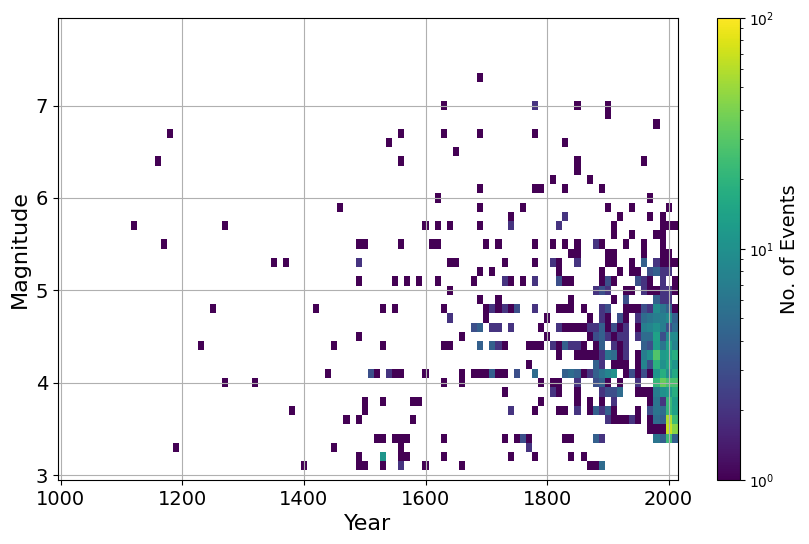

In [14]:
magnitude_bins = np.arange(3.0, 8.1, 0.1) # Bin the magnitudes from low to high every 0.1 M units
year_bins = np.arange(1000., 2021., 10.) # Bin the events by year
plot_magnitude_time_density(catalogue["Magnitude"], catalogue["year"],
                            mbins=magnitude_bins,
                            time_bins=year_bins)

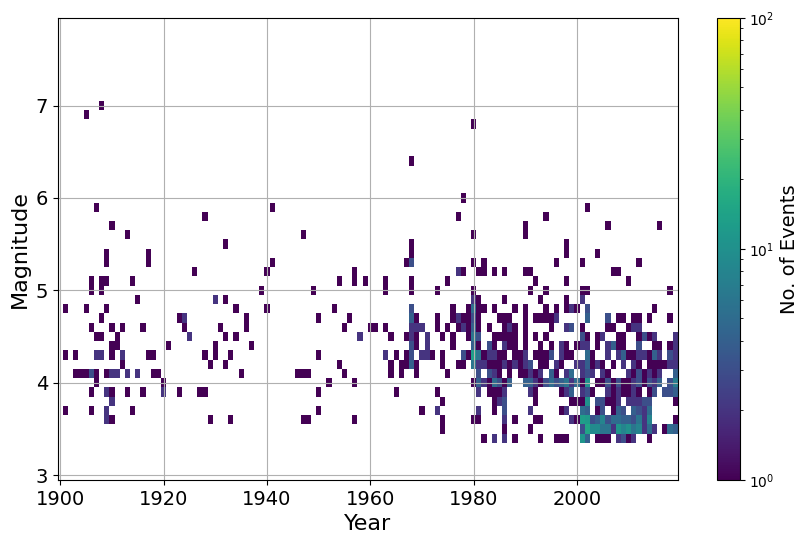

In [15]:
magnitude_bins = np.arange(3.0, 8.1, 0.1) # Bin the magnitudes from low to high every 0.1 M units
year_bins = np.arange(1900., 2021., 1.) # Bin the events by year
plot_magnitude_time_density(catalogue["Magnitude"], catalogue["year"],
                            mbins=magnitude_bins,
                            time_bins=year_bins)

(1500.0, 2020.0)

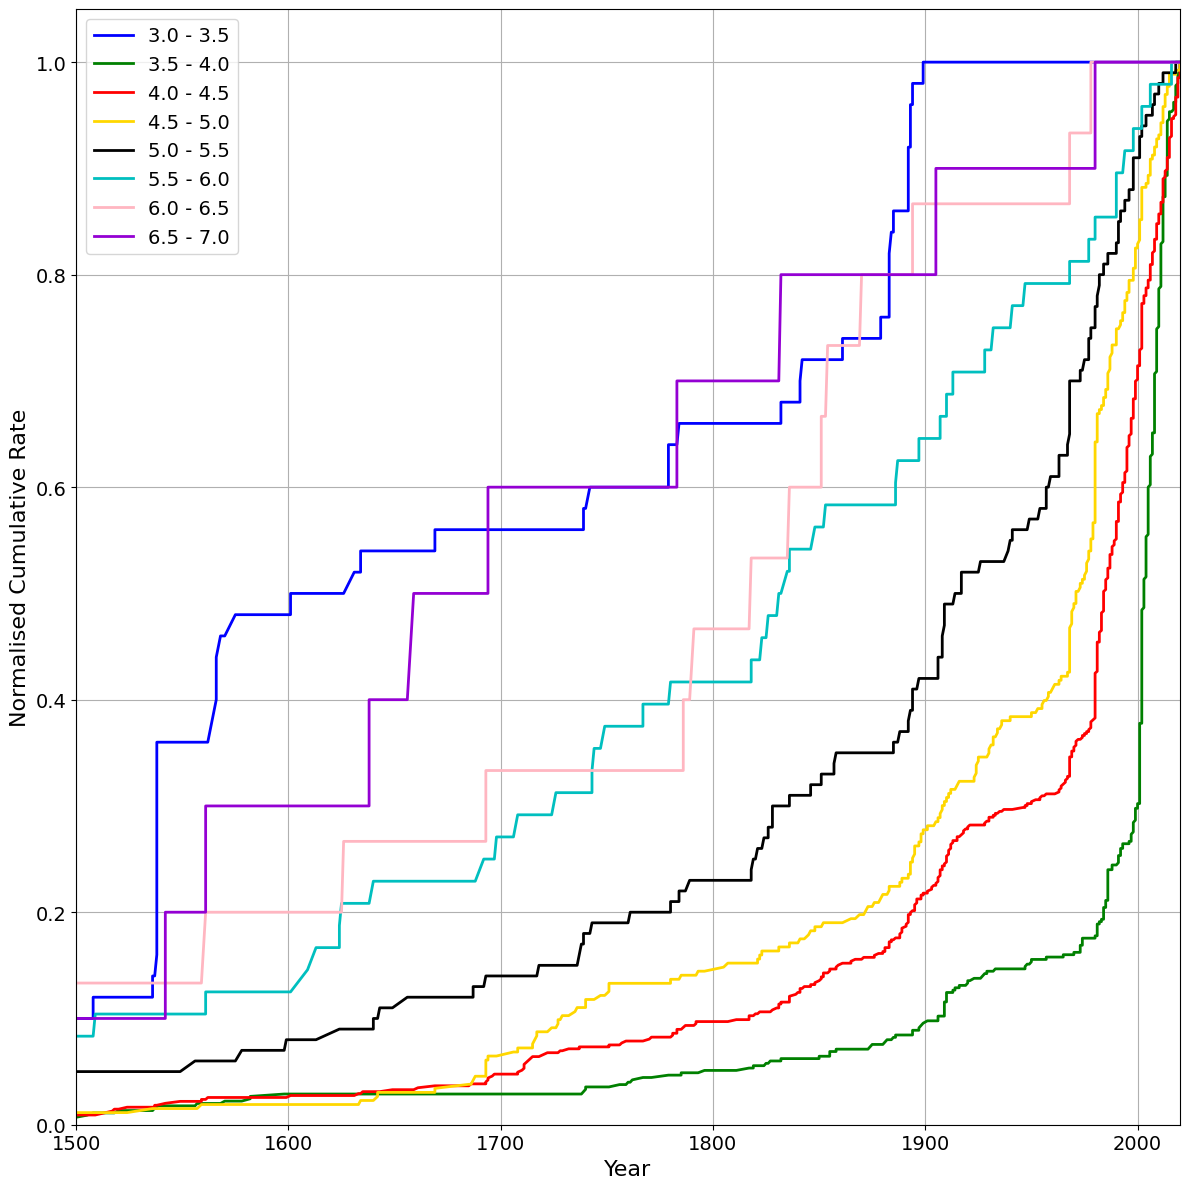

In [16]:
# First define the magnitude bins for estimating the changes in rates.
# Here we use bins from 3.0 to 6.5, spaced every 0.5 magnitude units
magnitude_bins = np.array([3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0])
# We could have done the same thing with magnitude_bins = np.arange(3.0, 7.0, 0.5)
fig, ax = cumulative_rates(catalogue["Magnitude"], catalogue["year"], magnitude_bins,)
ax.set_xlim(1500, 2020)

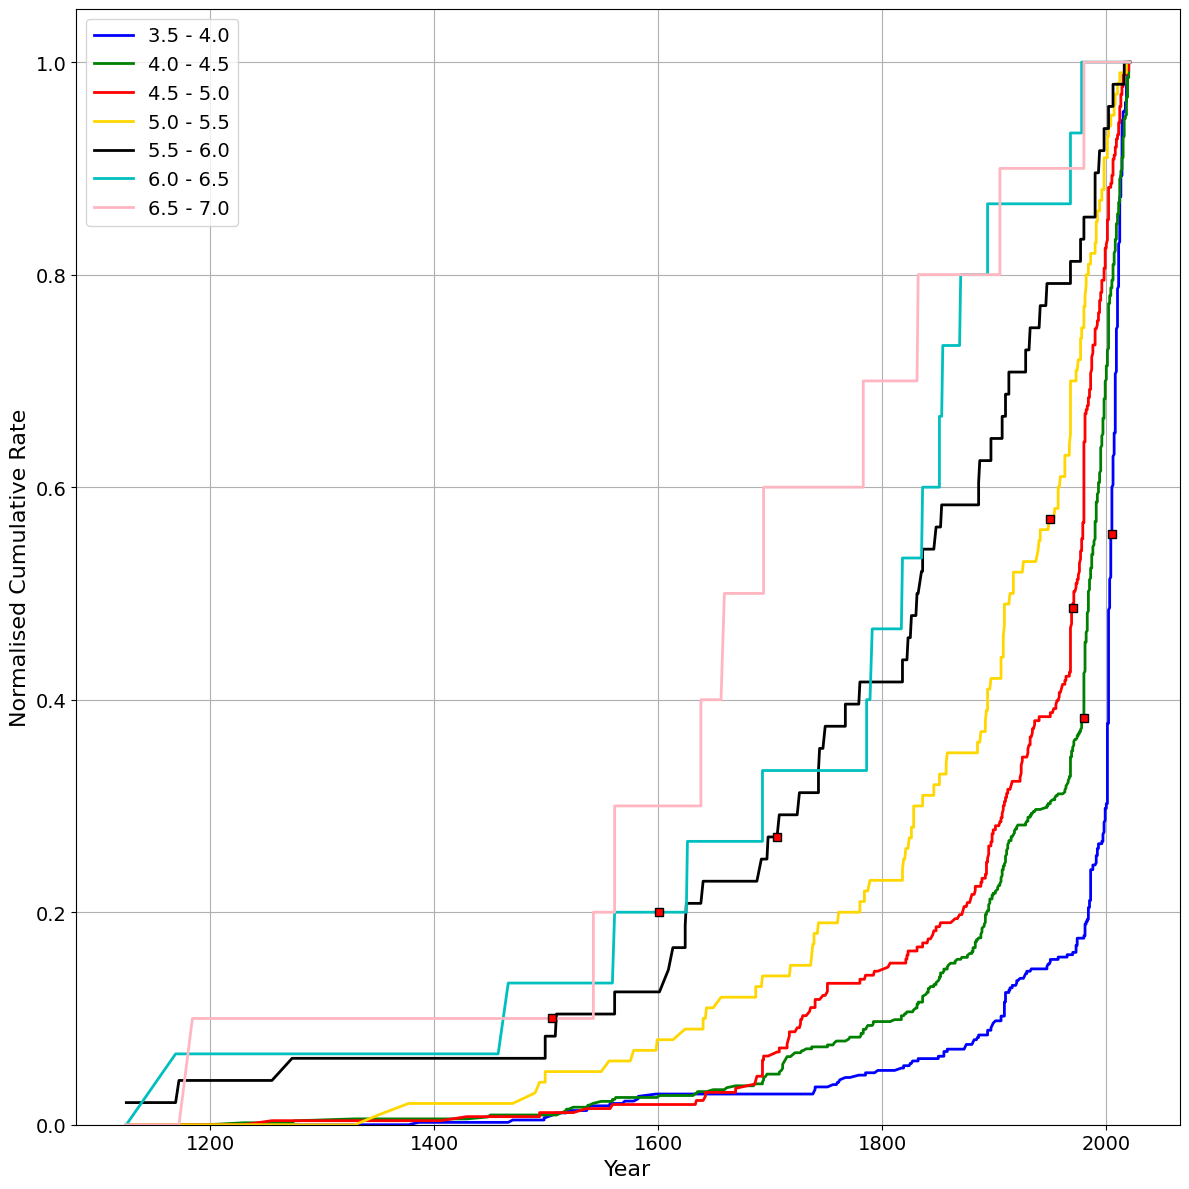

In [29]:
completeness_table = [[2005, 3.5],
                      [1980, 4.0],
                      [1970, 4.5],
                      [1950, 5.0],
                      [1700, 5.5],
                      [1600, 6.0],
                      [1500, 6.5],
                      [1000, 7.0]]

# Now we can input this table into the function to see where our "completenesses" lie on the plots
fig, ax = cumulative_rates(catalogue["Magnitude"], catalogue["year"], completeness_table)

# Estimating Recurrence

The core principal behind the methods we will look at are that we need to find the best estimate of the rate of events in different magnitude bins. <i>However</i> we can only make this estimation by adjusting for the period of time for which we believe that bin is <i>complete</i>.

In this example, we use our completeness table to define the bins for magnitude, which gives the following as the bins:

`3.0 <= M < 3.5`

`3.5 <= M < 4.0`

`4.0 <= M < 4.5`

`4.5 <= M < 5.0`

`5.0 <= M < 5.5`

`5.5 <= M < 6.0`

`6.0 <= M < 6.5`

`6.5 <= M < 7.0`

So, we need to count in each bin the number of earthquakes within the completeness period and the duration of the completeness period. This allows us to normalize the rate of events with respect to the completeness period. Finally we look at the cumulate normalized rates.

Pay attention step-by-step here ...

In [18]:
# A function to find the root of an equation - we'll come to this later!
from scipy.optimize import fsolve

In [31]:
magnitudes = catalogue["Magnitude"].to_numpy()
years = catalogue["year"].to_numpy()

# Our catalogue ends at the end of 2020
end_year = 2020.
# Number of bins is taken from the number of rows in the completeness table
nbins = len(completeness_table)
# The width of the bins is 0.5 M
bin_width = 0.5
# We will count the number of earthquakes, rates, midpoints of the bins and duration - so start with zeros
n_mags = np.zeros(nbins)
rates = np.zeros_like(n_mags)
midpoints = np.zeros_like(n_mags)
duration = np.zeros_like(n_mags)
# Loop through each row in the completeness table
for i, row in enumerate(completeness_table):
    # Starting year is the completeness year
    start_year = row[0]
    # Duration is the time between the end of the catalogue (incl. 2015) and
    # and the year of completeness 
    duration[i] = end_year - start_year + 1
    # A bit of logical work entering here, select the years >= the completeness year
    selected_years = years >= start_year
    # Define the upper and lower magnitude bounds of the bin
    mlow = row[1]
    mhigh = row[1] + bin_width
    midpoints[i] = (mlow + mhigh) / 2.
    # From the selected years find which earthquakes are within the magnitude range
    selected_magnitudes = np.logical_and(
        magnitudes[selected_years] >= mlow,
        magnitudes[selected_years] < mhigh
    )
    # Count the number of earthquakes selected
    n_mags[i] = np.sum(selected_magnitudes)
    # Divide by the duration of completeness for the magnitude bin
    rates[i] = float(n_mags[i]) / duration[i]


# Get the cumulative rates
cum_rates = np.zeros_like(n_mags)
for i in range(nbins):
    # Sum the rates greater than or equal to each bin
    cum_rates[i] = np.sum(rates[i:])
    
# Let's take a look at what we've just counted
print("Mlow  Mhigh   Mmid    Comp. Year  Num.Events   Rate (/yr)     Cum. Rate")
for i in range(nbins):
    print("%.1f     %.1f   %.2f          %.0f         %3g   %10.6f    %10.6f" %(
        completeness_table[i][1],
        completeness_table[i][1] + bin_width,
        completeness_table[i][1] + (bin_width / 2.),
        completeness_table[i][0],
        n_mags[i],
        rates[i],
        cum_rates[i]
    ))

Mlow  Mhigh   Mmid    Comp. Year  Num.Events   Rate (/yr)     Cum. Rate
3.5     4.0   3.75          2005         201    12.562500     24.239392
4.0     4.5   4.25          1980         338     8.243902     11.676892
4.5     5.0   4.75          1970         136     2.666667      3.432989
5.0     5.5   5.25          1950          43     0.605634      0.766323
5.5     6.0   5.75          1700          35     0.109034      0.160689
6.0     6.5   6.25          1600          12     0.028504      0.051655
6.5     7.0   6.75          1500           9     0.017274      0.023151
7.0     7.5   7.25          1000           6     0.005877      0.005877


### Now let's plot the incremental and cumulative rate of occurrence

Text(0, 0.5, 'Normalised Rate /yr')

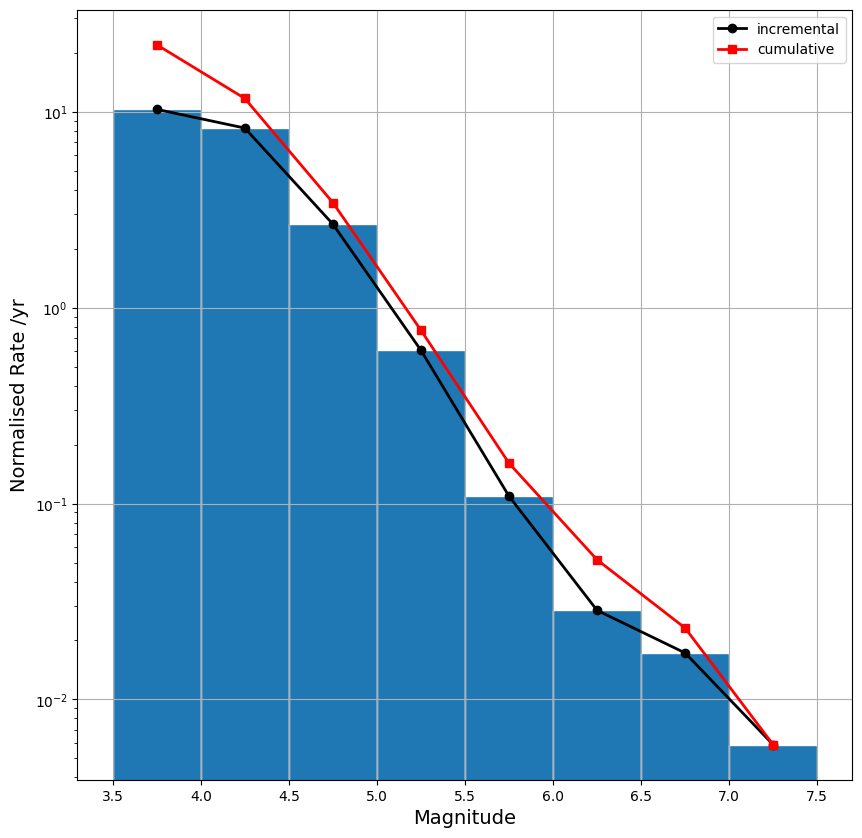

In [30]:
plt.figure(figsize=(10,10))
ctable = np.array(completeness_table)
plt.bar(ctable[:, 1], rates, 0.5, log=True, align="edge", edgecolor="w")
plt.plot(midpoints, rates, "ko-", lw=2, label="incremental")
plt.plot(midpoints, cum_rates, "rs-", lw=2, label="cumulative")
plt.legend()
plt.grid()
plt.xlabel("Magnitude", fontsize=14)
plt.ylabel("Normalised Rate /yr", fontsize=14)

### The Gutenberg-Richter Model

Looking at the data we can see that once we account for completeness in the catalogue, the relation between magnitude and the common logarithm of the <i>cumulative</i> number of events per year greater than that magnitude is (approximately) linear:

$\log_{10} \left( {Nc} \right) = a - bM$

Can we fit the a- and b-value?


### The Weichert (1980) Approach

Weichert (1980) proposes a maximum likelihood approach for finding parameters of the Gutenberg-Richter model for binned magnitudes of time-varying completeness. See the paper for the full derivation of the model.

Firstly, there is some calculus involved here, so we switch from the common logarithm to the natural logarithm.

$N_C = 10^{a - b \cdot M} = e^{\alpha - \beta \cdot M}$

where $\alpha = a\cdot\ln\left( {10} \right)$ and $\beta = b\cdot\ln\left( {10} \right)$

The likelihood function for the estimation of $\beta$ is found to be:

$L \left( {\beta | n_i, m_i, t_i} \right) = \frac{N!}{\prod_i n_i !}\cdot\prod_i \left( {\frac{t_i \exp\left( {-\beta m_i} \right)}{\sum_j t_j \exp \left( {-\beta m_j} \right)}} \right) ^{n_i}$

where $n_i$ is the number of earthquakes in magnitude bin $m_i$, with the completeness duration $t_i$, and $N$ is the total number of earthquakes <i>within the period of completeness</i>.


This has a maximum at $\ln L$ when:

$\frac{\sum_i t_i m_i \exp \left( {-\beta m_i} \right)}{\sum_j t_j \exp \left( {-\beta m_j} \right)} - \frac{\sum n_i m_i}{N} = 0$


The value for $\beta$ can be solved by iteration or Newton conjugate-gradient method (as below). Once this is known the rate of earthquakes above the minimum magnitude $m_{min}$ is determined from:

$N_C \left( {m \geq m_{min}} \right) = N \cdot \frac{\sum_i \exp\left( {-\beta m_i} \right)}{\sum_j t_j \exp\left( {-\beta m_j} \right)}$

From this we can infer a-value from the original form of the G-R model:

$a = \log_{10} \left( {N_C \left[{m \geq m_{min}}\right]} \right) + b \cdot m_{min}$

**That's the theory ... now see it in practice**

In [32]:
# This defines our likelihood function
def likelihood(beta, mags, nmags, duration):
    """
    Returns the minimum of the log-likelihood value. An optimum bvalue should bring
    this close to 0.0
    :param bvalue:
        b-value
    :param mags:
        mid-points of the magnitude bins
    :param nmags:
        Number of events in the specific magnitude bins
    :param duration:
        Completeness durations (in years) of the magnitude bins
    """
    mbar = np.sum(nmags * mags) / float(np.sum(nmags))
    numerator = np.sum(duration * mags * np.exp(-beta * mags))
    denominator = np.sum(duration * np.exp(-beta * mags))
    value = (numerator / denominator) - mbar
    return np.fabs(value)

# This applies the Weichert method of maximum likelihood estimation
def weichert(mags, nmags, duration, b0=1.0):
    """
    Implements the Weichert maximum likelihood estimator of rate and
    b-value for catalogues with time-varying completeness
    :param mags:
        mid-points of the magnitude bins
    :param nmags:
        Number of events in the specific magnitude bins
    :param duration:
        Completeness durations (in years) of the magnitude bins
    :param b0:
        Initial guess of b-value (optional, default = 1)
    :returns:
        a-value, b-value, stddev_a, stddev_b, rate_m0, stddev_rate_m0
    """
    # Initial guess at b-value, turn to beta
    beta0 = b0 * np.log(10.)

    # Find the optimum b-value such that the loglikelihood is equal to 0
    # For this we use scipy's fsolve function
    [beta] = fsolve(likelihood, x0=beta0, args=(mags, nmags, duration))
    b = beta / np.log(10.)

    # Now we have the b-value, need to get a-value
    # Get total number of earthquakes
    neq = float(np.sum(nmags))
    
    # We see this exp(-beta * m) being used a lot, so just calculate once and
    # save as a variable
    e_beta_m = np.exp(-beta * mags)
    
    # Get the rate of events above Mmin
    rate_m0 = neq * np.sum(e_beta_m) / np.sum(duration * e_beta_m)

    # Get the a-value from G-R: a = Nc + b * mmin
    a = np.log10(rate_m0) + b * mags[0]

    # Get the variance of b (from equation 9 of Weichert, 1980)
    var_beta = ((np.sum(duration * e_beta_m)) ** 2.) /\
        ((np.sum(duration * mags * e_beta_m) ** 2.) -
         (np.sum(duration * e_beta_m) * np.sum(duration * (mags ** 2.) * e_beta_m)))
    var_beta = (-1.0 / neq) * var_beta
    stddev_b = np.sqrt(var_beta) / np.log(10.)

    # Get the variance of rate >= M0
    stddev_rate_m0 = np.sqrt(rate_m0 / neq)
    return a, b, stddev_b, rate_m0, stddev_rate_m0


In [33]:
awc, bwc, sigma_bwc, rate_m0, stddev_rate_m0 = weichert(midpoints,
                                                        n_mags.astype(float),
                                                        duration)
print("a = %.4f  b = %.4f (+/- %.4f)  Rate M >= %.2f is %.3f (+/- %.4f))" % 
      (awc, bwc, sigma_bwc, completeness_table[0][1], rate_m0, stddev_rate_m0))

a = 5.1676  b = 0.9953 (+/- 0.0199)  Rate M >= 3.50 is 27.230 (+/- 0.1868))


Here the b-value is statistically identical to 1.0, which can be a common observation. Let's look at the model fit ...

Text(0, 0.5, 'Normalised Rate /yr')

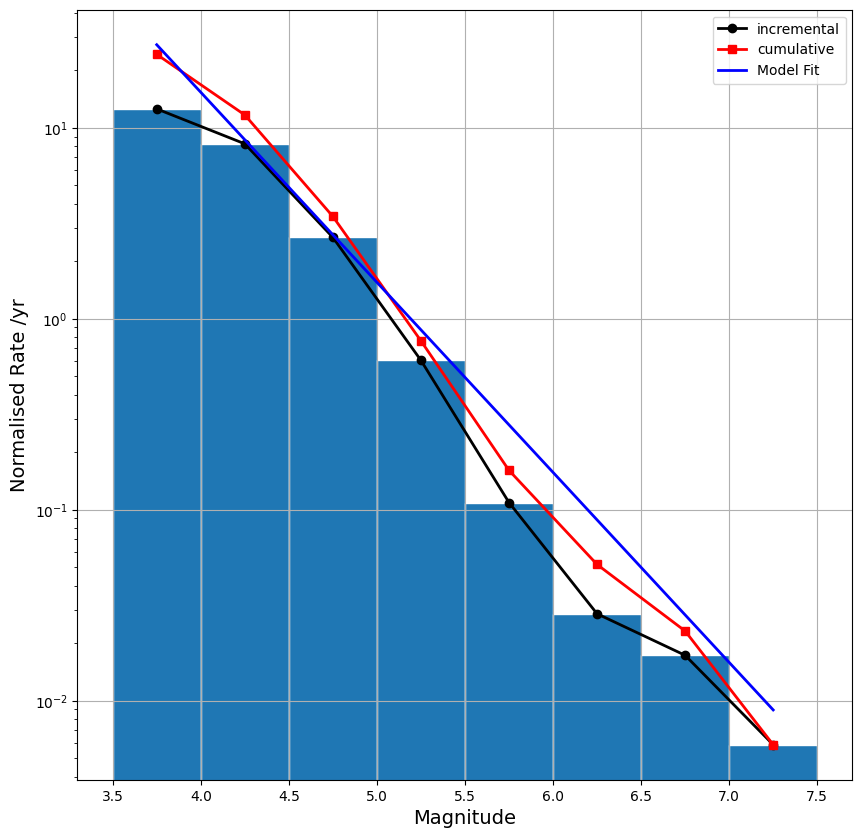

In [34]:
plt.figure(figsize=(10,10))

predicted_rates = 10.0 ** (awc - bwc * midpoints)
ctable = np.array(completeness_table)
plt.bar(ctable[:, 1], rates, 0.5, log=True, align="edge", edgecolor="w")
plt.plot(midpoints, rates, "ko-", lw=2, label="incremental")
plt.plot(midpoints, cum_rates, "rs-", lw=2, label="cumulative")
plt.plot(midpoints, predicted_rates, "b-", lw=2, label="Model Fit")
plt.legend()
plt.grid()
plt.xlabel("Magnitude", fontsize=14)
plt.ylabel("Normalised Rate /yr", fontsize=14)

The Weichert fit of the Gutenberg-Richter model seems to agree well at smaller magnitudes, but over-estimates the rate a little at larget magnitudes. There can be several reasons for this. The rate of the 3.5 - 4.0 magnitude bin seems to deviate from G-R behaviour, suggesting that the completeness may not be correctly estimate for the bin. It is possible that the "true" completeness is at some other point (say 3.75) so the actual rate of earthquakes is biased low. With maximum likelihood methods for estimating recurrence, incorrect completeness can result in biased estimates of a- and b-value. Other possible factors may be systematice biases introduced by the conversion of local or duration magnitudes to moment magnitudes in EMEC, or changes in the systematic magnitude estimation for the larger events.
